<a href="https://colab.research.google.com/github/swatikeshri-2005/Data_Analysis_Project/blob/main/Udemy_Course_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

In [2]:
from google.colab import files
uploaded = files.upload()

Saving udemy_courses.csv to udemy_courses.csv


In [3]:
df = pd.read_csv('udemy_courses.csv')

In [4]:
df.head(4)

,course_id,course_title,url,is_paid,price,num_subscribers,num_reviews,num_lectures,level,content_duration,published_timestamp,subject
0,1070968,Ultimate Investment Banking Course,https://www.udemy.com/ultimate-investment-bank...,True,200,2147,23,51,All Levels,1.5,2017-01-18T20:58:58Z,Business Finance
1,1113822,Complete GST Course & Certification - Grow You...,https://www.udemy.com/goods-and-services-tax/,True,75,2792,923,274,All Levels,39.0,2017-03-09T16:34:20Z,Business Finance
2,1006314,Financial Modeling for Business Analysts and C...,https://www.udemy.com/financial-modeling-for-b...,True,45,2174,74,51,Intermediate Level,2.5,2016-12-19T19:26:30Z,Business Finance
3,1210588,Beginner to Pro - Financial Analysis in Excel ...,https://www.udemy.com/complete-excel-finance-c...,True,95,2451,11,36,All Levels,3.0,2017-05-30T20:07:24Z,Business Finance


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3678 entries, 0 to 3677
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   course_id            3678 non-null   int64  
 1   course_title         3678 non-null   object 
 2   url                  3678 non-null   object 
 3   is_paid              3678 non-null   bool   
 4   price                3678 non-null   int64  
 5   num_subscribers      3678 non-null   int64  
 6   num_reviews          3678 non-null   int64  
 7   num_lectures         3678 non-null   int64  
 8   level                3678 non-null   object 
 9   content_duration     3678 non-null   float64
 10  published_timestamp  3678 non-null   object 
 11  subject              3678 non-null   object 
dtypes: bool(1), float64(1), int64(5), object(5)
memory usage: 319.8+ KB


In [6]:
df.isnull().sum()
df.head(5)

,course_id,course_title,url,is_paid,price,num_subscribers,num_reviews,num_lectures,level,content_duration,published_timestamp,subject
0,1070968,Ultimate Investment Banking Course,https://www.udemy.com/ultimate-investment-bank...,True,200,2147,23,51,All Levels,1.5,2017-01-18T20:58:58Z,Business Finance
1,1113822,Complete GST Course & Certification - Grow You...,https://www.udemy.com/goods-and-services-tax/,True,75,2792,923,274,All Levels,39.0,2017-03-09T16:34:20Z,Business Finance
2,1006314,Financial Modeling for Business Analysts and C...,https://www.udemy.com/financial-modeling-for-b...,True,45,2174,74,51,Intermediate Level,2.5,2016-12-19T19:26:30Z,Business Finance
3,1210588,Beginner to Pro - Financial Analysis in Excel ...,https://www.udemy.com/complete-excel-finance-c...,True,95,2451,11,36,All Levels,3.0,2017-05-30T20:07:24Z,Business Finance
4,1011058,How To Maximize Your Profits Trading Options,https://www.udemy.com/how-to-maximize-your-pro...,True,200,1276,45,26,Intermediate Level,2.0,2016-12-13T14:57:18Z,Business Finance


In [7]:
#Finding out the duplicates
df[df['course_title'] == 'Essentials of money: Get a financial Life !']

,course_id,course_title,url,is_paid,price,num_subscribers,num_reviews,num_lectures,level,content_duration,published_timestamp,subject


In [8]:
df['subject'].value_counts()

,count
subject,
Web Development,1200
Business Finance,1195
Musical Instruments,680
Graphic Design,603


Text(0, 0.5, 'NUMBER OF COURSES(subject wise)')

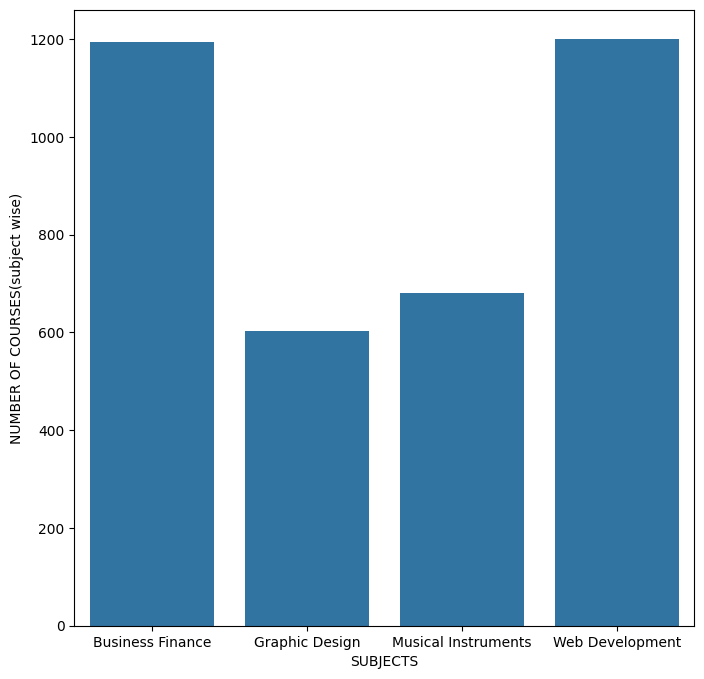

In [9]:
plt.figure(figsize=(8,8))
sns.countplot(data=df,x='subject')
plt.xlabel('SUBJECTS')
plt.ylabel('NUMBER OF COURSES(subject wise)')

Text(0, 0.5, 'NUMBER OF COURSES(LEVEL WISE)')

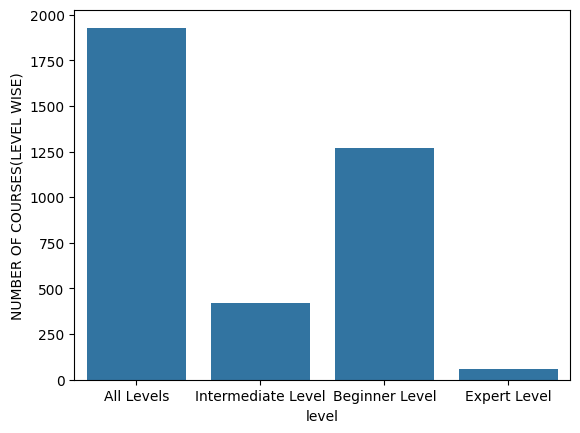

In [10]:
sns.countplot(x = 'level',data = df)
plt.ylabel('NUMBER OF COURSES(LEVEL WISE)')

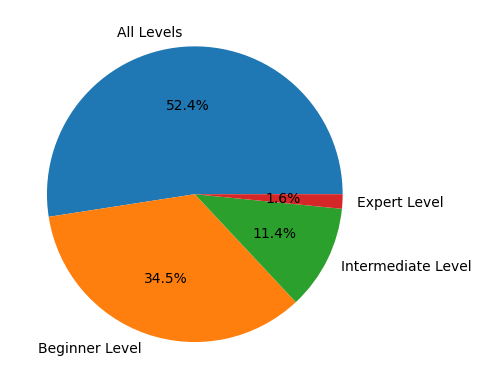

In [11]:
#Pie Plot
df_level = df['level'].value_counts()
plt.pie(df_level, normalize=True, autopct='%1.1f%%', labels=df_level.index)
plt.show()

In [12]:
#Number of lectures are free and paid
df.groupby('is_paid')['num_lectures'].sum()

,num_lectures
is_paid,
False,6639
True,140881


<Axes: xlabel='level', ylabel='num_lectures'>

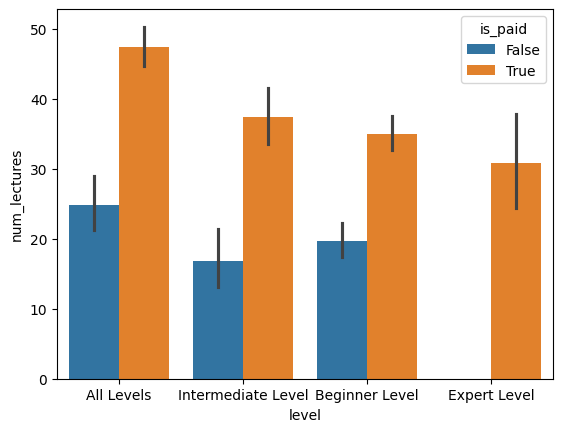

In [13]:

#lets visulaize it along with levels

sns.barplot(data = df, x = 'level', y = 'num_lectures',hue = 'is_paid')

In [14]:

df.groupby('level')['num_subscribers'].sum()

,num_subscribers
level,
All Levels,6915076
Beginner Level,4051843
Expert Level,50196
Intermediate Level,742005


In [15]:
'''Visualizing
1. Finding the most enrolled course
2. Top #10 popular courses
3. Courses having highest rating
'''

'Visualizing\n1. Finding the most enrolled course\n2. Top #10 popular courses\n3. Courses having highest rating\n'

In [16]:
#Finding the most enrolled course
df.groupby('course_title')['num_subscribers'].sum().sort_values(ascending = False).head(1)

,num_subscribers
course_title,
Learn HTML5 Programming From Scratch,268923


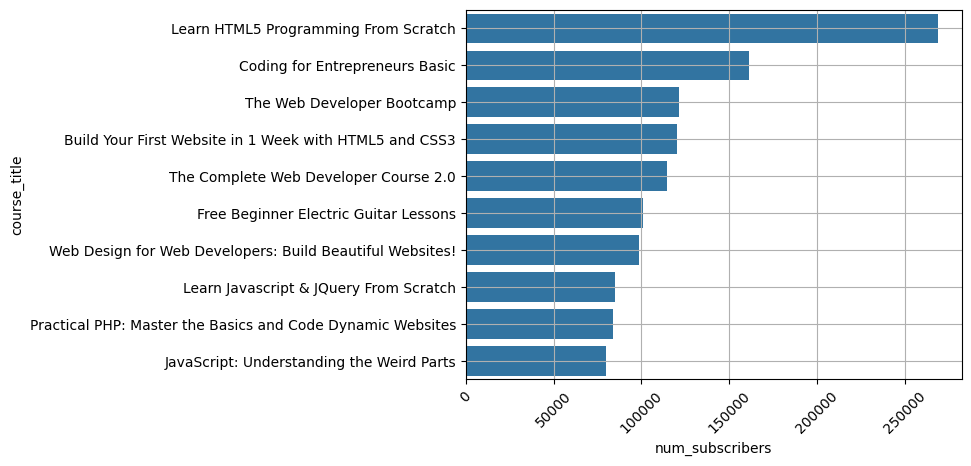

In [17]:
#Top #10 popular courses
t10 = df.sort_values(by = 'num_subscribers', ascending = False).head(10)
sns.barplot(y = 'course_title', x = 'num_subscribers', data = t10)
plt.xticks(rotation = 45)
plt.grid('True')

([<matplotlib.patches.Wedge at 0x7c8c61581400>,
 [Text(0.8550051060045231, 0.6920738896289864, 'Learn HTML5 Programming From Scratch'),
  Text(-0.21595114469371093, 1.0785940399916347, 'Coding for Entrepreneurs Basic'),
  Text(-0.8702823397965822, 0.6727619557006671, 'The Web Developer Bootcamp'),
  Text(-1.0988336340472846, 0.05064232110042187, 'Build Your First Website in 1 Week with HTML5 and CSS3'),
  Text(-0.9388796756284078, -0.5731535175604316, 'The Complete Web Developer Course 2.0'),
  Text(-0.5050340055290071, -0.9772106493787954, 'Free Beginner Electric Guitar Lessons'),
  Text(0.03202430573041809, -1.0995337392924716, 'Web Design for Web Developers: Build Beautiful Websites!'),
  Text(0.5257627341849995, -0.9662160976418855, 'Learn Web Designing & HTML5/CSS3 Essentials in 4-Hours'),
  Text(0.8832327894079433, -0.6556674764807722, 'Learn Javascript & JQuery From Scratch'),
  Text(1.0754002305650356, -0.23133167552384262, 'Practical PHP: Master the Basics and Code Dynamic Web

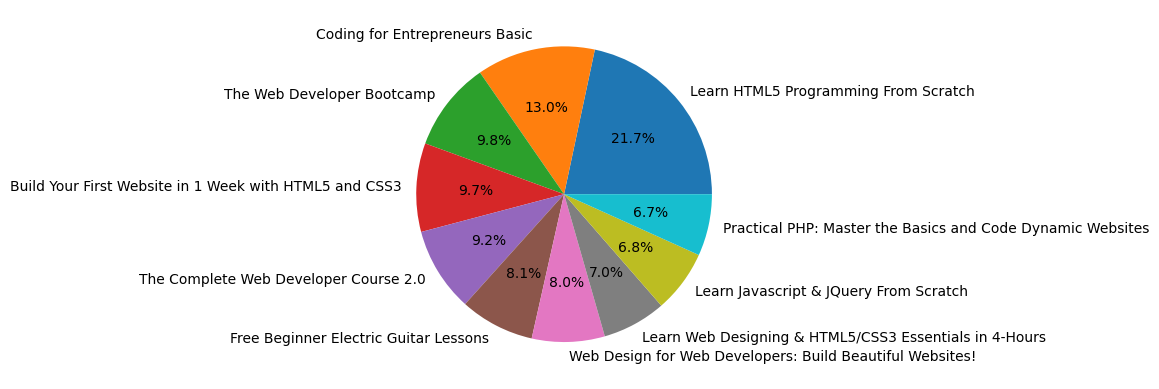

In [18]:
#on pie plot
Popular_courses = df.groupby('course_title')['num_subscribers'].sum().sort_values(ascending = False).head(10)
plt.pie(Popular_courses, normalize = True, autopct = '%1.1f%%', labels = Popular_courses.index)

In [19]:
#Courses having highest rating
df.groupby('subject')['num_reviews'].sum().sort_values(ascending = False)

,num_reviews
subject,
Web Development,430025
Business Finance,75902
Graphic Design,37070
Musical Instruments,31724


<Axes: xlabel='price', ylabel='num_subscribers'>

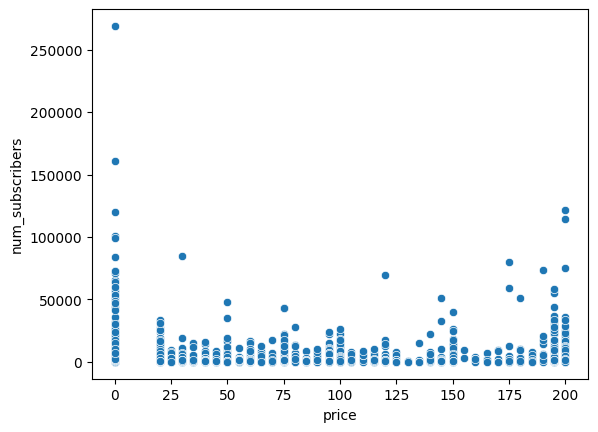

In [22]:
#Effect of price on subscribers
sns.scatterplot(x = 'price', y = 'num_subscribers', data = df)